
\begin{equation}
D_1(s) = 51s^3 + 5s^2 + 29s + 17
\end{equation}

\begin{equation}
D_2(s) = s^3 + 6s^2 + 11s + 6
\end{equation}

\begin{equation}
D_3(s) = s^4 + 10s^3 + 35s^2 + 50s + 24
\end{equation}

\begin{equation}
D_4(s) = 3s^4 + 5s^3 + 4s^2 + 9s + 63
\end{equation}



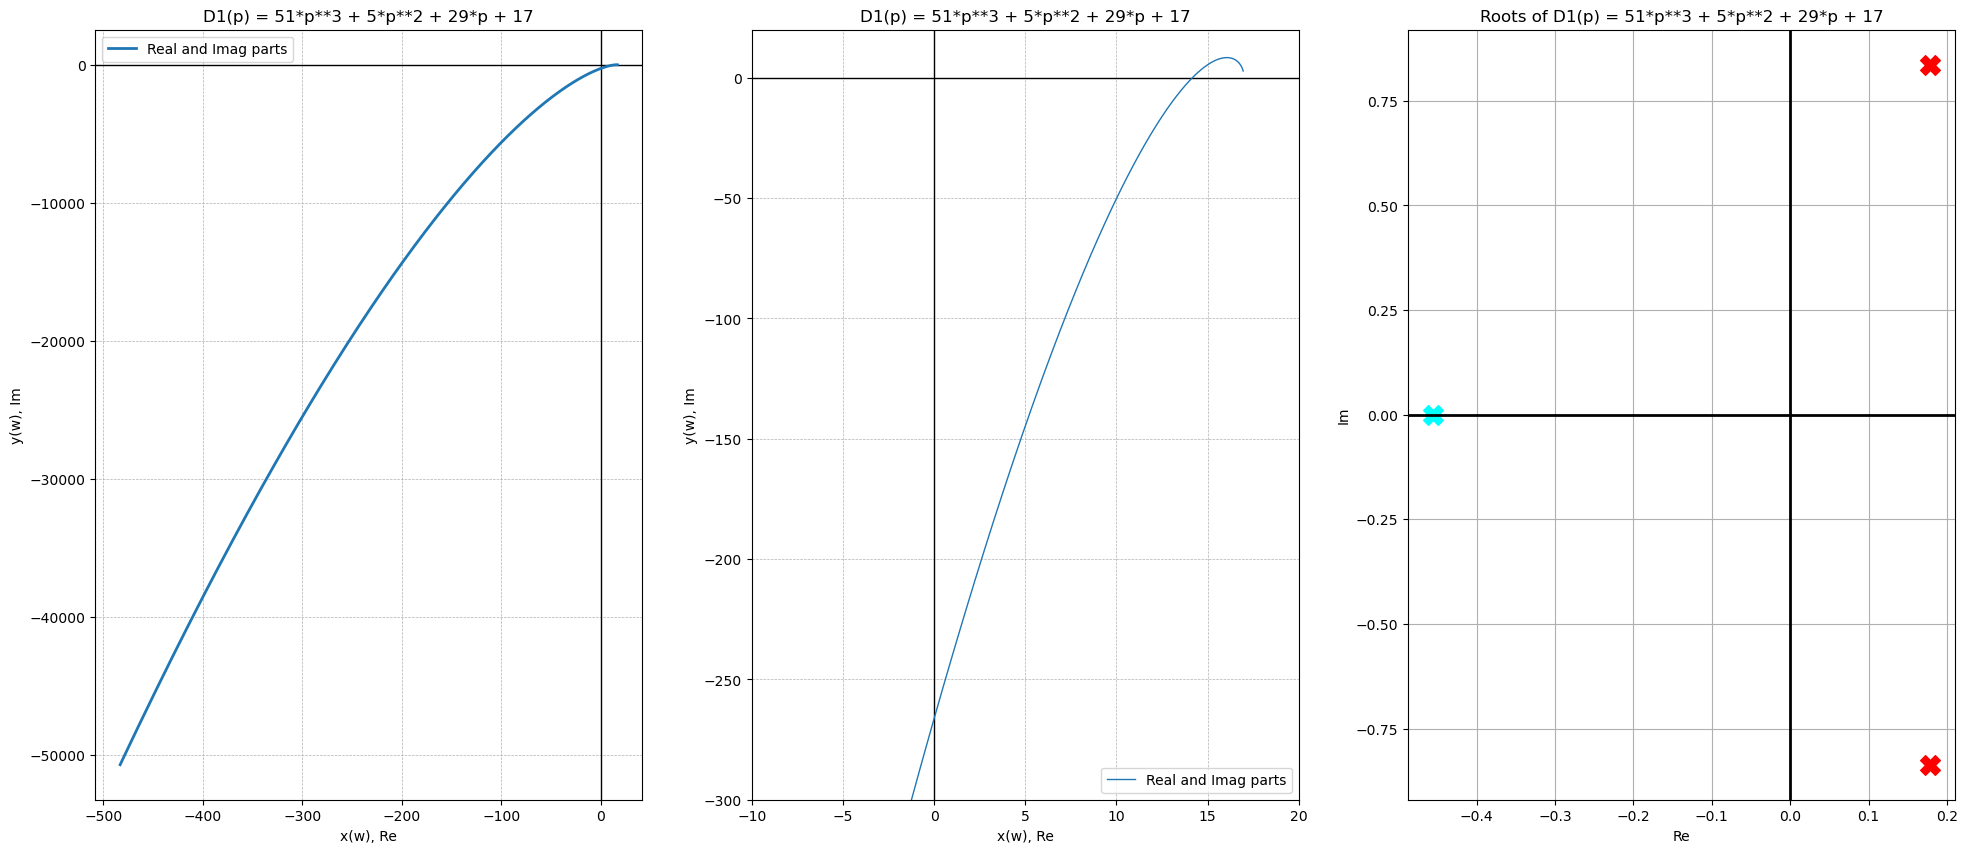

Order of system W1(p) is 3
System is stable: False



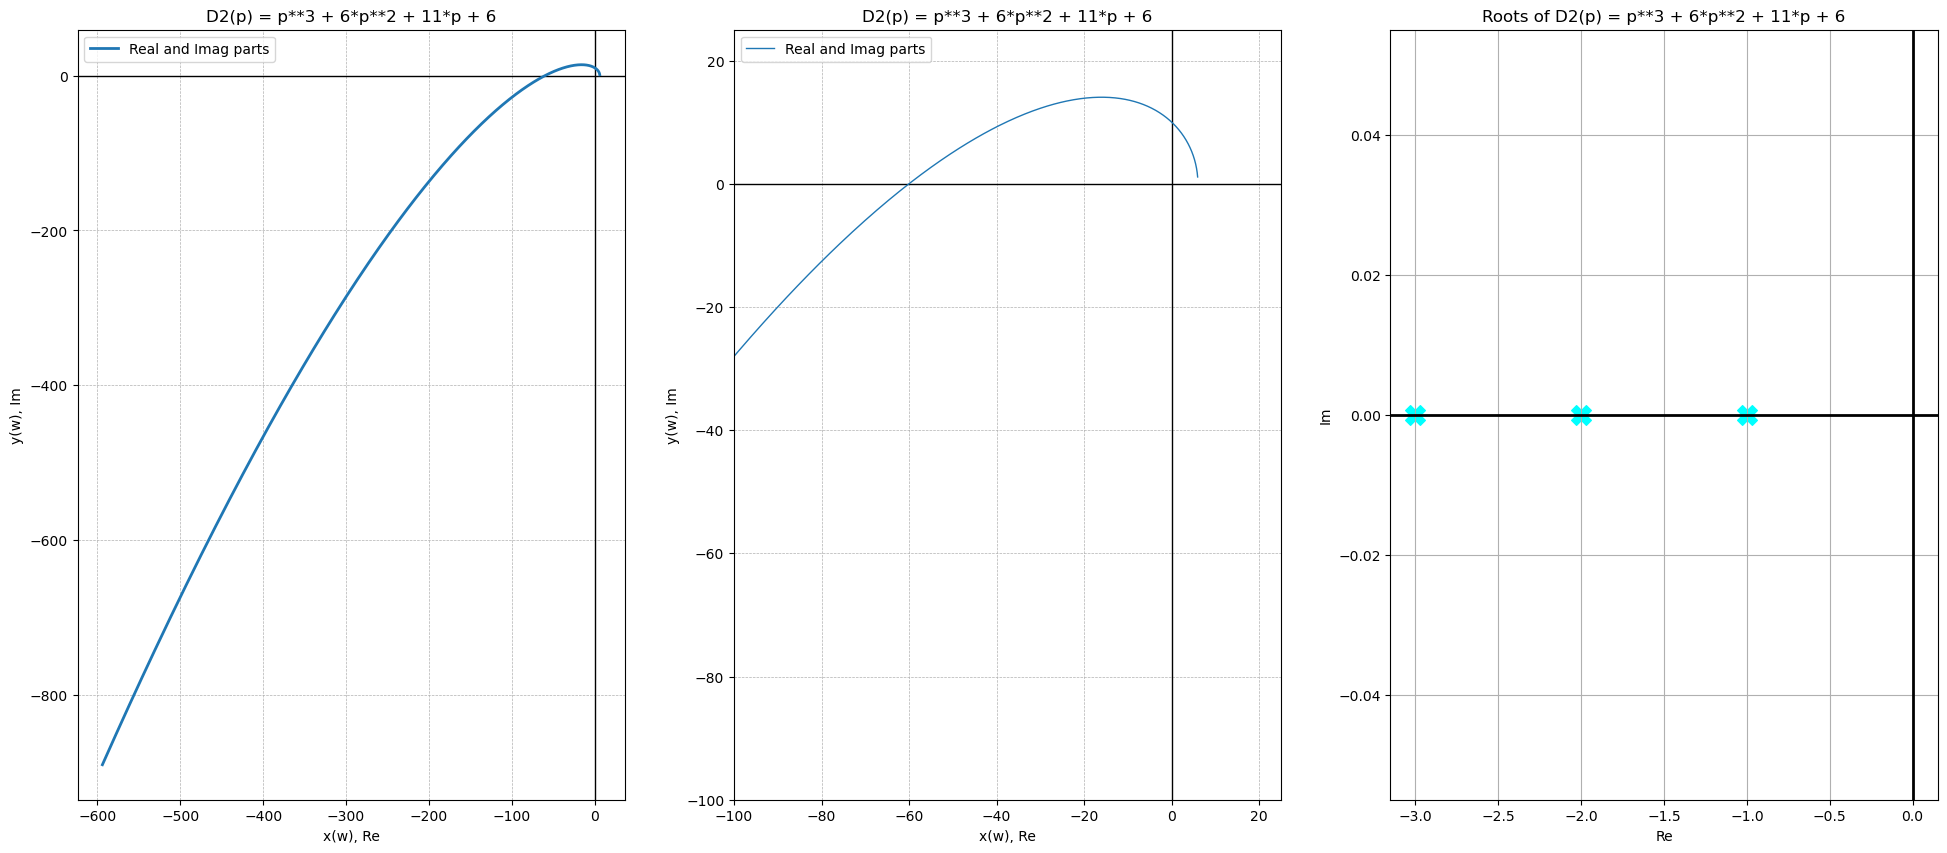

Order of system W2(p) is 3
System is stable: True



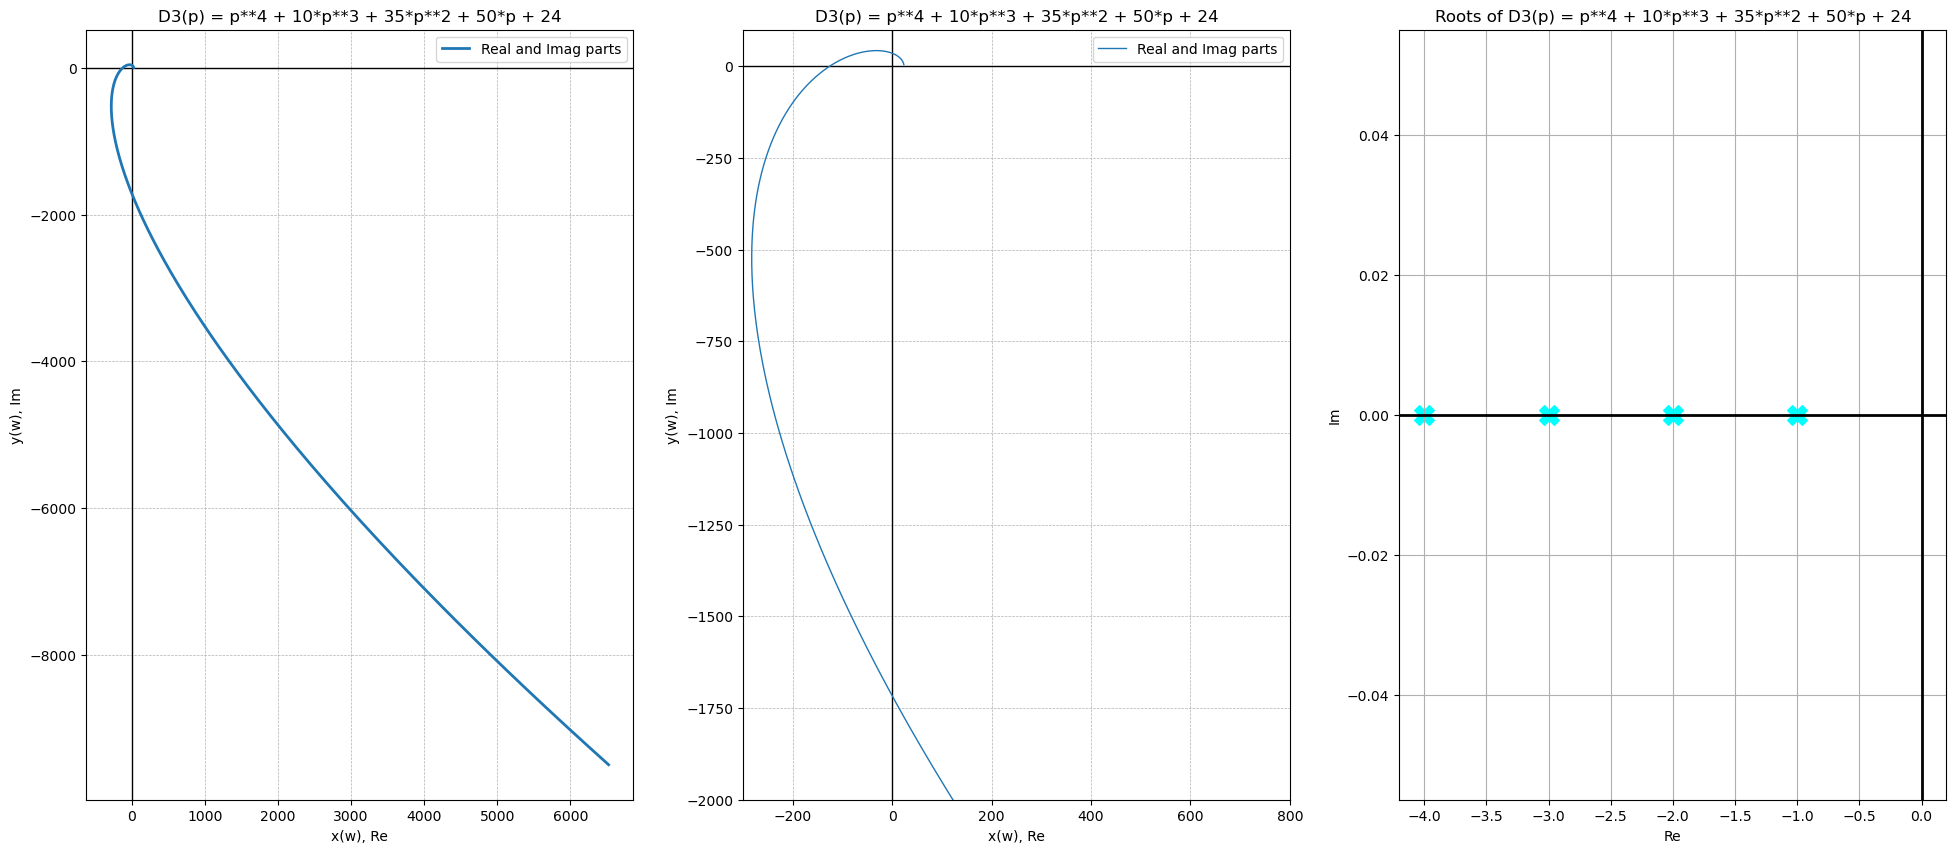

Order of system W3(p) is 4
System is stable: True



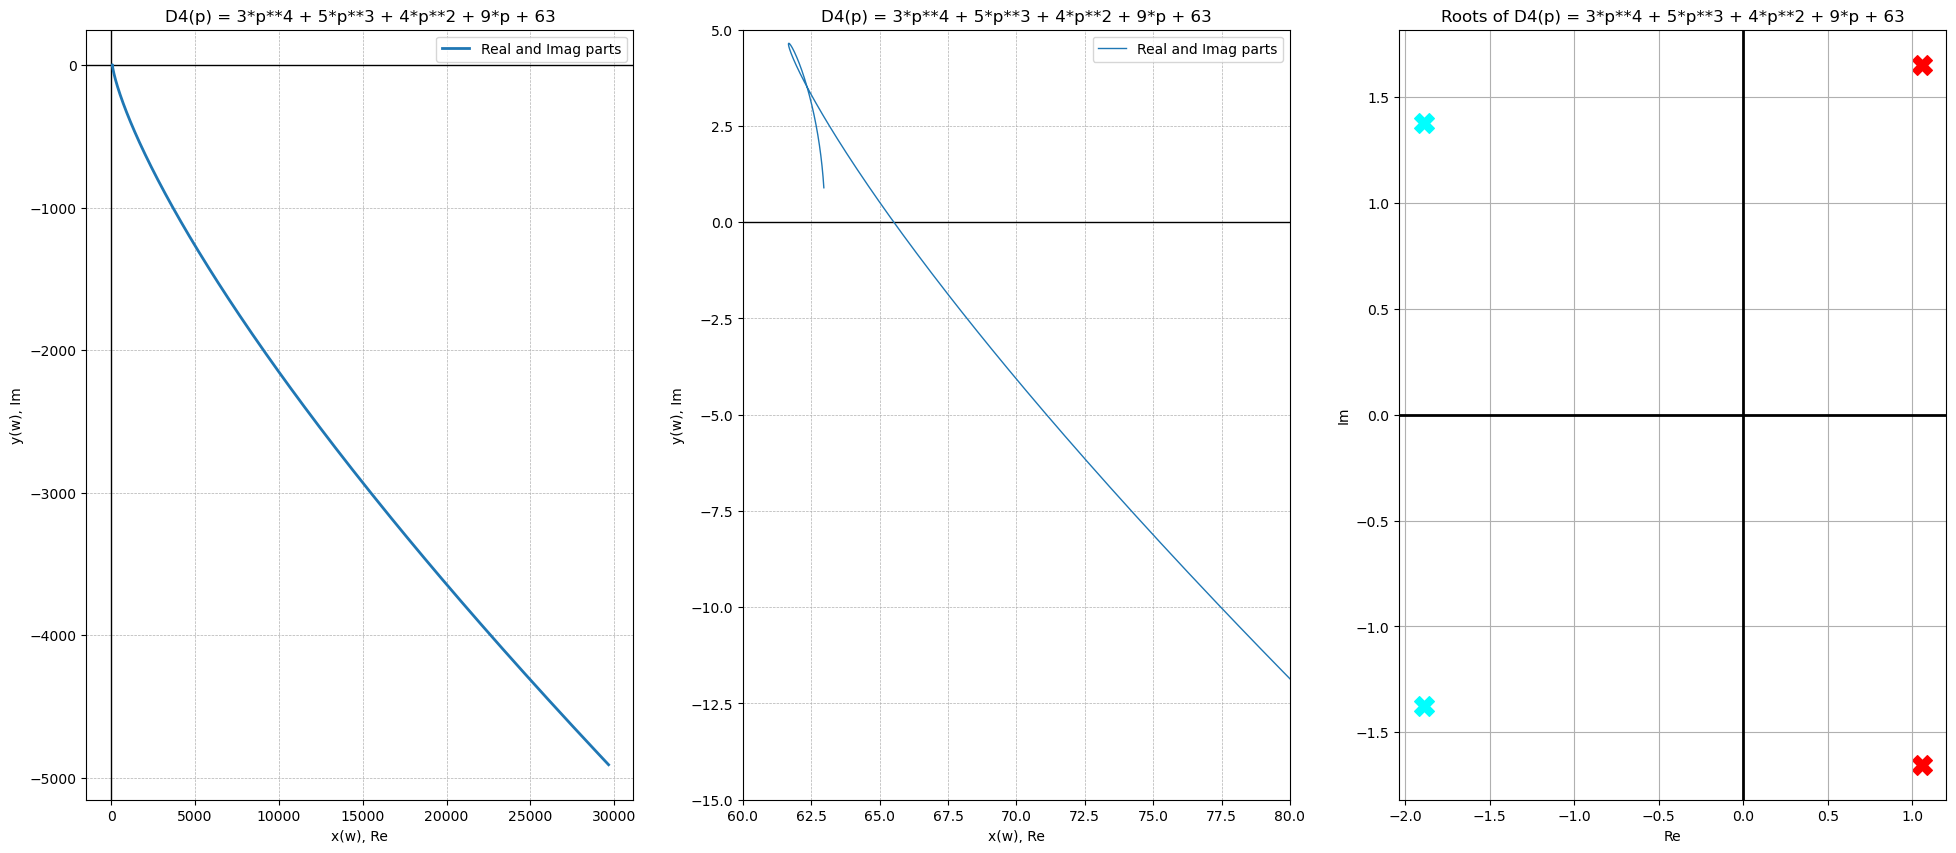

Order of system W4(p) is 4
System is stable: False



In [29]:
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt
from scipy import signal

# -----------------------------------------------------------------------------
# -- Mikhailov curves
# -----------------------------------------------------------------------------

def curve_1(s):
    return (51 * s**3 + 5 * s**2 + 29 * s + 17)

def curve_2(s):
    return s**3 + 6*s**2 + 11*s + 6

def curve_3(s):
    return (s**4 + 10*s**3 + 35*s**2 + 50*s + 24)

def curve_4(s):
    return (3 * s**4 + 5 * s**3 + 4 * s**2 + 9 * s + 63)

# -----------------------------------------------------------------------------
# -- Functions
# -----------------------------------------------------------------------------

def get_system_order(curve, p_sym):
    return len(sym.Poly(curve(p_sym)).all_coeffs()) - 1

def check_stability(curve, p_sym):
    roots = np.roots(sym.Poly(curve(p_sym)).all_coeffs())
    return all(r.real < 0 for r in roots), roots

def plot_curve(curve, p, roots, title, xlim=None, ylim=None):
    plt.figure(figsize=(24, 10))

    plt.subplot(1, 3, 1, polar=False)
    plt.xlabel("x(w), Re")
    plt.ylabel("y(w), Im")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.axvline(0, color='k', linewidth=1)
    plt.axhline(0, color='k', linewidth=1)
    plt.title(f"{title}")
    plt.plot(np.real(curve(p)), np.imag(curve(p)), linewidth='2', label='Real and Imag parts')
    plt.legend()

    plt.subplot(1, 3, 2, polar=False)
    plt.xlabel("x(w), Re")
    plt.ylabel("y(w), Im")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.axvline(0, color='k', linewidth=1)
    plt.axhline(0, color='k', linewidth=1)
    plt.title(f"{title}")
    plt.plot(np.real(curve(p)), np.imag(curve(p)), linewidth='1', label='Real and Imag parts')
    if xlim and ylim:
        plt.xlim(xlim[0], xlim[1])
        plt.ylim(ylim[0], ylim[1])
    plt.legend()

    plt.subplot(1, 3, 3, polar=False)
    plt.axvline(0, color='k', linewidth=2)
    plt.axhline(0, color='k', linewidth=2)
    for r in roots:
        if r.real < 0:
            plt.scatter(r.real, r.imag, color='cyan', marker='X', s=200)
        else:
            plt.scatter(r.real, r.imag, color='red', marker='X', s=200)
            
    plt.title(f'Roots of {title}')
    plt.xlabel('Re')
    plt.ylabel('Im')
    plt.grid()

    plt.show()

# -----------------------------------------------------------------------------
# -- Main code
# -----------------------------------------------------------------------------

w = np.logspace(-1, 1, 10**3)
p_sym = sym.Symbol('p')
p = 1j * w

n1 = get_system_order(curve_1, p_sym)
n2 = get_system_order(curve_2, p_sym)
n3 = get_system_order(curve_3, p_sym)
n4 = get_system_order(curve_4, p_sym)



is_stable_1, roots_1 = check_stability(curve_1, p_sym)
is_stable_2, roots_2 = check_stability(curve_2, p_sym)
is_stable_3, roots_3 = check_stability(curve_3, p_sym)
is_stable_4, roots_4 = check_stability(curve_4, p_sym)



plot_curve(curve_1, p, roots_1, title=f'D1(p) = {sym.expand(curve_1(p_sym))}', xlim=(-10, 20), ylim=(-300, 20))
print(f'Order of system W1(p) is {n1}')
print(f'System is stable: {is_stable_1}\n')

plot_curve(curve_2, p, roots_2, title=f'D2(p) = {sym.expand(curve_2(p_sym))}', xlim=(-100, 25), ylim=(-100, 25))
print(f'Order of system W2(p) is {n2}')
print(f'System is stable: {is_stable_2}\n')

plot_curve(curve_3, p, roots_3, title=f'D3(p) = {sym.expand(curve_3(p_sym))}', xlim=(-300, 800), ylim=(-2000, 100))
print(f'Order of system W3(p) is {n3}')
print(f'System is stable: {is_stable_3}\n')

plot_curve(curve_4, p, roots_4, title=f'D4(p) = {sym.expand(curve_4(p_sym))}', xlim=(60, 80), ylim=(-15, 5))
print(f'Order of system W4(p) is {n4}')
print(f'System is stable: {is_stable_4}\n')
